In [394]:
import pandas as pd
import numpy as np
import cv2
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [395]:
ROOT = Path("/Users/shikhar/Desktop/projects/Image-drug")
root_directory = ROOT / "images" / "Week1_22123"

In [396]:
image_meta = pd.read_csv('BBBC021_v1_image.csv')
moa_labels = pd.read_csv('BBBC021_v1_moa.csv')

In [397]:
image_meta.head()

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,Image_Metadata_Compound,Image_Metadata_Concentration
0,4,233,G10_s1_w1BEDC2073-A983-4B98-95E9-84466707A25D.tif,Week4/Week4_27481,G10_s1_w2DCEC82F3-05F7-4F2F-B779-C5DF9698141E.tif,Week4/Week4_27481,G10_s1_w43CD51CBC-2370-471F-BA01-EE250B14B3C8.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
1,4,234,G10_s2_w11C3B9BCC-E48F-4C2F-9D31-8F46D8B5B972.tif,Week4/Week4_27481,G10_s2_w2570437EF-C8DC-4074-8D63-7FA3A7271FEE.tif,Week4/Week4_27481,G10_s2_w400B21F33-BDAB-4363-92C2-F4FB7545F08C.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
2,4,235,G10_s3_w1F4FCE330-C71C-4CA3-9815-EAF9B9876EB5.tif,Week4/Week4_27481,G10_s3_w2194A9AC7-369B-4D84-99C0-DA809B0042B8.tif,Week4/Week4_27481,G10_s3_w4E0452054-9FC1-41AB-8C5B-D0ACD058991F.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
3,4,236,G10_s4_w1747818B4-FFA7-40EE-B0A0-6A5974AF2644.tif,Week4/Week4_27481,G10_s4_w298D4652F-B5BF-49F2-BE51-8149DF83EAFD.tif,Week4/Week4_27481,G10_s4_w42648D36D-6B77-41CD-B520-6E4C533D9ABC.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
4,4,473,G10_s1_w10034568D-CC12-43C3-93A9-DC3782099DD3.tif,Week4/Week4_27521,G10_s1_w2A29ED14B-952C-4BA1-89B9-4F92B6DADEB4.tif,Week4/Week4_27521,G10_s1_w4DAA2E9D1-F6E9-45FA-ADC0-D341B647A680.tif,Week4/Week4_27521,Week4_27521,G10,2,5-fluorouracil,0.003


In [398]:
moa_labels.head()

,compound,concentration,moa
0,PP-2,3.0,Epithelial
1,emetine,0.3,Protein synthesis
2,AZ258,1.0,Aurora kinase inhibitors
3,cytochalasin B,10.0,Actin disruptors
4,ALLN,3.0,Protein degradation


In [399]:
image_meta.isna().sum()

TableNumber                     0
ImageNumber                     0
Image_FileName_DAPI             0
Image_PathName_DAPI             0
Image_FileName_Tubulin          0
Image_PathName_Tubulin          0
Image_FileName_Actin            0
Image_PathName_Actin            0
Image_Metadata_Plate_DAPI       0
Image_Metadata_Well_DAPI        0
Replicate                       0
Image_Metadata_Compound         0
Image_Metadata_Concentration    0
dtype: int64

In [400]:
#Let's check at the number of drugs
print("Number of unique compounds in MOA labels:", moa_labels.compound.nunique())

Number of unique compounds in MOA labels: 39


In [401]:
#Checking the number of mechanism of actions (MOAs) in the dataset
print("Number of unique MOAs in MOA labels:", moa_labels.moa.nunique())

Number of unique MOAs in MOA labels: 13


In [402]:
#Checking whether compound have same moa. Return false is so 
moa_labels.groupby('compound')['moa'].nunique().eq(1).all()


np.True_

In [403]:
#Let's check the rows
moa_labels.shape

(104, 3)

In [404]:
image_meta.head()

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,Image_Metadata_Compound,Image_Metadata_Concentration
0,4,233,G10_s1_w1BEDC2073-A983-4B98-95E9-84466707A25D.tif,Week4/Week4_27481,G10_s1_w2DCEC82F3-05F7-4F2F-B779-C5DF9698141E.tif,Week4/Week4_27481,G10_s1_w43CD51CBC-2370-471F-BA01-EE250B14B3C8.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
1,4,234,G10_s2_w11C3B9BCC-E48F-4C2F-9D31-8F46D8B5B972.tif,Week4/Week4_27481,G10_s2_w2570437EF-C8DC-4074-8D63-7FA3A7271FEE.tif,Week4/Week4_27481,G10_s2_w400B21F33-BDAB-4363-92C2-F4FB7545F08C.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
2,4,235,G10_s3_w1F4FCE330-C71C-4CA3-9815-EAF9B9876EB5.tif,Week4/Week4_27481,G10_s3_w2194A9AC7-369B-4D84-99C0-DA809B0042B8.tif,Week4/Week4_27481,G10_s3_w4E0452054-9FC1-41AB-8C5B-D0ACD058991F.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
3,4,236,G10_s4_w1747818B4-FFA7-40EE-B0A0-6A5974AF2644.tif,Week4/Week4_27481,G10_s4_w298D4652F-B5BF-49F2-BE51-8149DF83EAFD.tif,Week4/Week4_27481,G10_s4_w42648D36D-6B77-41CD-B520-6E4C533D9ABC.tif,Week4/Week4_27481,Week4_27481,G10,1,5-fluorouracil,0.003
4,4,473,G10_s1_w10034568D-CC12-43C3-93A9-DC3782099DD3.tif,Week4/Week4_27521,G10_s1_w2A29ED14B-952C-4BA1-89B9-4F92B6DADEB4.tif,Week4/Week4_27521,G10_s1_w4DAA2E9D1-F6E9-45FA-ADC0-D341B647A680.tif,Week4/Week4_27521,Week4_27521,G10,2,5-fluorouracil,0.003


In [405]:
#Let's look into image_meta datasets
image_meta.Image_Metadata_Compound.nunique()

113

In [406]:
#Let's check if the DMSO is present for atleast each experiment
dmso = image_meta[image_meta["Image_Metadata_Compound"] == "DMSO"]

print(len(dmso))  # number of DMSO photo rows

1320


In [407]:
#Checkign whether all plates have DMSO or not
all_plates = image_meta["Image_Metadata_Plate_DAPI"].unique()
dmso_plates = dmso["Image_Metadata_Plate_DAPI"].unique()

In [408]:
print("Total plates:", len(all_plates))
print("Plates with DMSO:", len(dmso_plates))

Total plates: 55
Plates with DMSO: 55


In [409]:
#To check whether all plates have DMSO or not
no_dmso = 0
for plate in all_plates:
    if plate not in dmso_plates:
        no_dmso += 1

print(no_dmso, "plates do not have DMSO")

#Looks like all plates have DMSO

0 plates do not have DMSO


In [410]:
dmso_wells = dmso.drop_duplicates(
    subset=["Image_Metadata_Plate_DAPI", "Image_Metadata_Well_DAPI"]
)

wells_per_plate = dmso_wells.groupby("Image_Metadata_Plate_DAPI").size()

print(wells_per_plate.describe())
print(wells_per_plate.sort_values().head())

count    55.0
mean      6.0
std       0.0
min       6.0
25%       6.0
50%       6.0
75%       6.0
max       6.0
dtype: float64
Image_Metadata_Plate_DAPI
Week10_40111    6
Week5_28961     6
Week5_29301     6
Week5_29321     6
Week5_29341     6
dtype: int64


In [411]:
#Check which position has dmso
dmso_positions = dmso_wells.groupby("Image_Metadata_Plate_DAPI")["Image_Metadata_Well_DAPI"].apply(list)
dmso_positions


Image_Metadata_Plate_DAPI
Week10_40111    [B02, C02, D02, E11, F11, G11]
Week10_40115    [B02, C02, D02, E11, F11, G11]
Week10_40119    [B02, C02, D02, E11, F11, G11]
Week1_22123     [B02, C02, D02, E11, F11, G11]
Week1_22141     [B02, C02, D02, E11, F11, G11]
Week1_22161     [B02, C02, D02, E11, F11, G11]
Week1_22361     [B02, C02, D02, E11, F11, G11]
Week1_22381     [B02, C02, D02, E11, F11, G11]
Week1_22401     [B02, C02, D02, E11, F11, G11]
Week2_24121     [B02, C02, D02, E11, F11, G11]
Week2_24141     [B02, C02, D02, E11, F11, G11]
Week2_24161     [B02, C02, D02, E11, F11, G11]
Week2_24361     [B02, C02, D02, E11, F11, G11]
Week2_24381     [B02, C02, D02, E11, F11, G11]
Week2_24401     [B02, C02, D02, E11, F11, G11]
Week3_25421     [B02, C02, D02, E11, F11, G11]
Week3_25441     [B02, C02, D02, E11, F11, G11]
Week3_25461     [B02, C02, D02, E11, F11, G11]
Week3_25681     [B02, C02, D02, E11, F11, G11]
Week3_25701     [B02, C02, D02, E11, F11, G11]
Week3_25721     [B02, C02, D02, E1

In [412]:
#Check how much length of each plate has dmso
dmso_positions.apply(len).describe()

count    55.0
mean      6.0
std       0.0
min       6.0
25%       6.0
50%       6.0
75%       6.0
max       6.0
Name: Image_Metadata_Well_DAPI, dtype: float64

In [413]:
#Merging the two csv now 
moa_labels.head()

,compound,concentration,moa
0,PP-2,3.0,Epithelial
1,emetine,0.3,Protein synthesis
2,AZ258,1.0,Aurora kinase inhibitors
3,cytochalasin B,10.0,Actin disruptors
4,ALLN,3.0,Protein degradation


In [414]:
#We need to merge the two datasets on compound name and concentration. But first we need to change the name of the coloumns in image_meta to match the coloumns in moa_labels. The coloumns are Image_Metadata_Compound and Image_Metadata_Concentration. We will change them to compound and concentration respectively.
image_meta.rename(columns={"Image_Metadata_Compound": "compound", "Image_Metadata_Concentration": "concentration"}, inplace=True)



In [415]:
#Now let's merge the two datsets together
final_data = pd.merge(image_meta, moa_labels, on=["compound", "concentration"], how="inner")

In [416]:
final_data.groupby(["compound", "concentration"]).size()

compound     concentration
ALLN         3.00             12
             100.00           12
AZ-A         0.10             12
             0.30             12
             1.00             12
                              ..
vincristine  0.03             12
             0.10             12
             0.30             12
             1.00             12
             3.00             12
Length: 104, dtype: int64

In [417]:
#How many drugs do we have
final_data["compound"].nunique()

39

Text(0, 0.5, 'Number of Images')

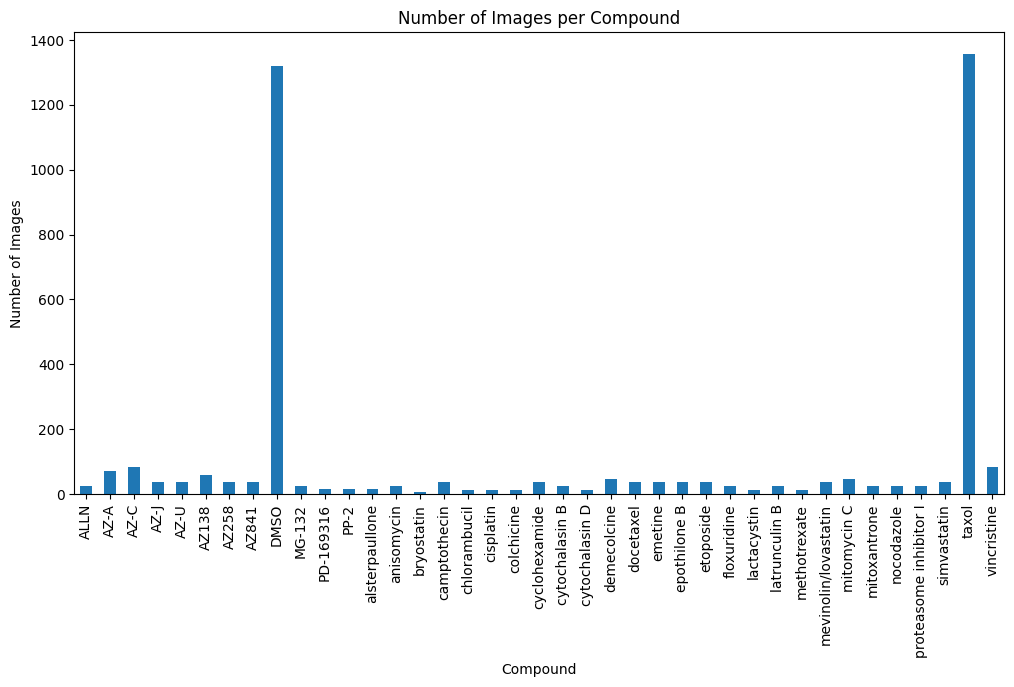

In [418]:
#Plot the number of images per compound
compound_counts = final_data.groupby("compound").size()
plt.figure(figsize=(12, 6))
compound_counts.plot(kind="bar")
plt.title("Number of Images per Compound")
plt.xlabel("Compound")
plt.ylabel("Number of Images")

Taxol and DMSO has have the larges compound

To do list for what we can do
- Check if a single compound experiment is done in 1 week and it is not continued towards the another week
- Check if the durgs have equal number of doses on each week
- Check if the doses are distributed properly and is consist of the same dose


In [419]:
final_data.head()

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,compound,concentration,moa
0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-9CC39666813B.tif,Week1/Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-2093F0815C94.tif,Week1/Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-FAB019FE8996.tif,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-73A4F7EC5F1A.tif,Week1/Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-D67A89A3A125.tif,Week1/Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-ABE5D4A3C761.tif,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-7174BFBF3643.tif,Week1/Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-22AE0E990BF1.tif,Week1/Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-D53AA25DB02B.tif,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
3,1,10,Week1_150607_B04_s2_w1F649C703-6FA8-406F-8575-CBEAC160B4BD.tif,Week1/Week1_22123,Week1_150607_B04_s2_w2802CC81E-56F9-41C5-A6C2-E5A0F233ED3B.tif,Week1/Week1_22123,Week1_150607_B04_s2_w4342F300D-60F8-4256-A637-F1367E14BE5E.tif,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
4,1,251,Week1_150607_B04_s3_w1B0B8AAC7-F2AD-4756-939C-6151431D5637.tif,Week1/Week1_22141,Week1_150607_B04_s3_w25C7FD77E-FDC4-471F-A512-6018D98F1D6A.tif,Week1/Week1_22141,Week1_150607_B04_s3_w42BD03411-D32F-4179-A6C5-C4D27E937A93.tif,Week1/Week1_22141,Week1_22141,B04,2,cytochalasin B,10.0,Actin disruptors


In [420]:
#Convert week col into int
final_data['week'] = (
    final_data['Image_Metadata_Plate_DAPI']
    .str.extract(r'Week(\d+)', expand=False)
    .astype(int)
)

In [421]:
compound_week = final_data.groupby(['week'])['compound']

It seems that every drug is unique for every week experiment and only DMSO and taxol are used throughout the week but DMSO is a solution and Taxol are...

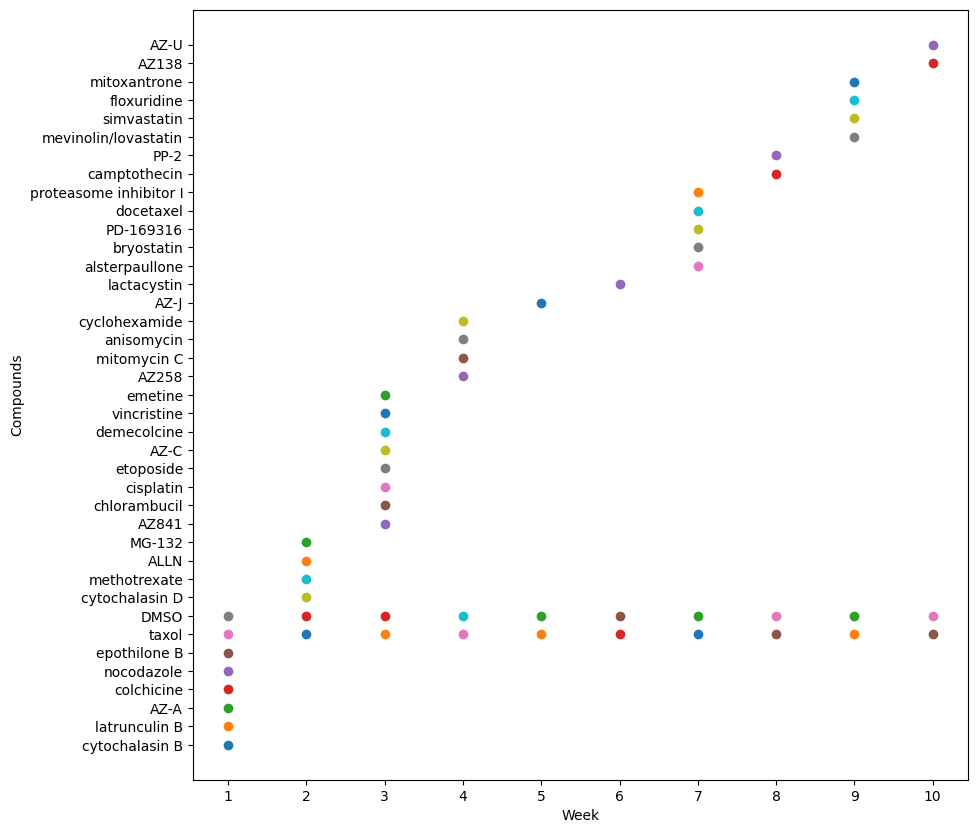

In [422]:
#I want to now see whether there is different drugs for different week except for DMSO and taxol and hasn't been used for another week
plt.figure(figsize=(10, 10))
plt.xticks(range(1,11))
plt.xlabel("Week")
plt.ylabel("Compounds")
for week, compounds in compound_week:
    for c in compounds.unique():
        plt.scatter(week, c)

plt.show()

In [423]:
#We now want to check whether the drugs every week had equal number of doses or not
weekly_doses = final_data.groupby(['week', 'compound'])['concentration']

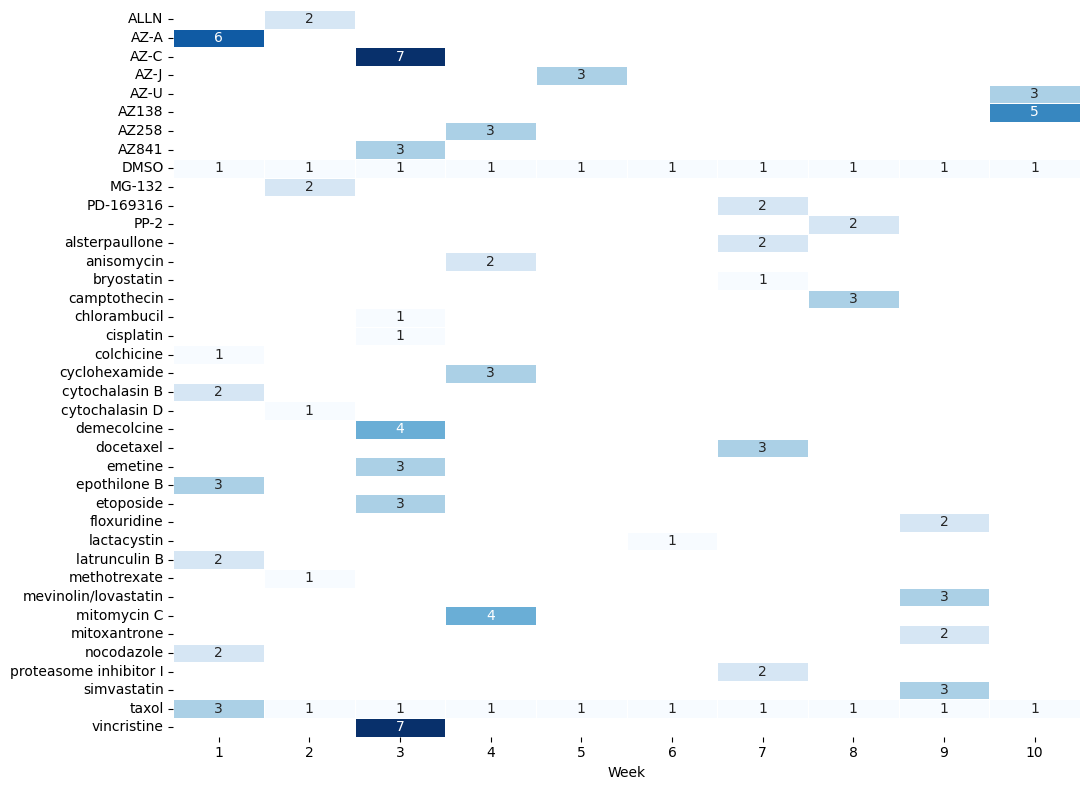

In [424]:
# Heatmap of Compound Concentrations by Week

pivot = final_data.pivot_table(
    index="compound", columns="week",
    values="concentration", aggfunc="nunique", fill_value=0
)

plt.figure(figsize=(11, 8))
sns.heatmap(pivot, annot=True, mask=pivot==0,cmap="Blues", cbar=False,
            linewidths=0.5, linecolor="white")
plt.xlabel("Week")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [425]:
#To check how the dose are incremented if they are incremented for each drug
weekly_doses

In [426]:
d = final_data.drop_duplicates(subset=["compound", "concentration"])

print(d.groupby("compound")["concentration"].apply(lambda s: sorted(s.unique())).to_string())

#It looks like the dosage was increased by a factor of 3 

compound
ALLN                                                   [3.0, 100.0]
AZ-A                               [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
AZ-C                      [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
AZ-J                                               [1.0, 3.0, 10.0]
AZ-U                                               [1.0, 3.0, 10.0]
AZ138                                    [0.03, 0.1, 0.3, 1.0, 3.0]
AZ258                                               [0.1, 0.3, 1.0]
AZ841                                               [0.1, 0.3, 1.0]
DMSO                                                          [0.0]
MG-132                                                   [0.1, 3.0]
PD-169316                                               [3.0, 10.0]
PP-2                                                    [3.0, 10.0]
alsterpaullone                                           [1.0, 3.0]
anisomycin                                               [0.3, 1.0]
bryostatin                             

In [427]:
#Group by mechanism and count two things for each class: how many rows (treatments) and how many unique drugs.
pd.set_option("display.max_colwidth", None)
moa_labels[moa_labels["moa"] != "DMSO"].groupby("moa").agg(
    treatments=("compound", "size"),
    drugs=("compound", "nunique"),
    drugs_name = ("compound", lambda x: ', '.join(sorted(x.unique()))))

,treatments,drugs,drugs_name
moa,,,
Actin disruptors,5,3,"cytochalasin B, cytochalasin D, latrunculin B"
Aurora kinase inhibitors,12,3,"AZ-A, AZ258, AZ841"
Cholesterol-lowering,6,2,"mevinolin/lovastatin, simvastatin"
DNA damage,9,4,"chlorambucil, cisplatin, etoposide, mitomycin C"
DNA replication,8,4,"camptothecin, floxuridine, methotrexate, mitoxantrone"
Eg5 inhibitors,12,2,"AZ-C, AZ138"
Epithelial,8,3,"AZ-J, AZ-U, PP-2"
Kinase inhibitors,5,3,"PD-169316, alsterpaullone, bryostatin"
Microtubule destabilizers,14,4,"colchicine, demecolcine, nocodazole, vincristine"


In [428]:
final_data

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,compound,concentration,moa,week
0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-9CC39666813B.tif,Week1/Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-2093F0815C94.tif,Week1/Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-FAB019FE8996.tif,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors,1
1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-73A4F7EC5F1A.tif,Week1/Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-D67A89A3A125.tif,Week1/Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-ABE5D4A3C761.tif,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors,1
2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-7174BFBF3643.tif,Week1/Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-22AE0E990BF1.tif,Week1/Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-D53AA25DB02B.tif,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors,1
3,1,10,Week1_150607_B04_s2_w1F649C703-6FA8-406F-8575-CBEAC160B4BD.tif,Week1/Week1_22123,Week1_150607_B04_s2_w2802CC81E-56F9-41C5-A6C2-E5A0F233ED3B.tif,Week1/Week1_22123,Week1_150607_B04_s2_w4342F300D-60F8-4256-A637-F1367E14BE5E.tif,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors,1
4,1,251,Week1_150607_B04_s3_w1B0B8AAC7-F2AD-4756-939C-6151431D5637.tif,Week1/Week1_22141,Week1_150607_B04_s3_w25C7FD77E-FDC4-471F-A512-6018D98F1D6A.tif,Week1/Week1_22141,Week1_150607_B04_s3_w42BD03411-D32F-4179-A6C5-C4D27E937A93.tif,Week1/Week1_22141,Week1_22141,B04,2,cytochalasin B,10.0,Actin disruptors,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3843,9,3560,Week9_090907_F11_s4_w19580FF4D-DC3D-4BD0-93FE-41D8A371978B.tif,Week9/Week9_39301,Week9_090907_F11_s4_w2DC65EC6F-BDCA-4B05-B243-3B68A6972727.tif,Week9/Week9_39301,Week9_090907_F11_s4_w45699A0F4-9AEE-4CD4-8973-0063D470F0EC.tif,Week9/Week9_39301,Week9_39301,F11,3,DMSO,0.0,DMSO,9
3844,9,3597,Week9_090907_G11_s1_w1EDE534D2-FCEE-4F92-A30B-08F4D0039853.tif,Week9/Week9_39301,Week9_090907_G11_s1_w26A22E27F-6A81-43F5-9587-539BF02C37DC.tif,Week9/Week9_39301,Week9_090907_G11_s1_w4554A2BF7-0D53-4D27-BF92-76D2CF5D9E37.tif,Week9/Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO,9
3845,9,3598,Week9_090907_G11_s2_w10B010F39-3B4B-4DCB-8E34-6ED26F9145C1.tif,Week9/Week9_39301,Week9_090907_G11_s2_w2720AC778-3F85-4293-8D75-41B4279AD9C2.tif,Week9/Week9_39301,Week9_090907_G11_s2_w49B290958-BCF2-4DDD-B0E9-D72CBBE387ED.tif,Week9/Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO,9
3846,9,3599,Week9_090907_G11_s3_w10394282C-6D3D-4E0E-9FA3-7FD9197A1F72.tif,Week9/Week9_39301,Week9_090907_G11_s3_w24C59DB62-E99B-4284-BAD2-CE3DB9064E73.tif,Week9/Week9_39301,Week9_090907_G11_s3_w471FE25C8-2477-456F-9D74-9C37E075EF8F.tif,Week9/Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO,9


In [429]:
dna_images = final_data['Image_FileName_DAPI']
actin_images = final_data['Image_FileName_Actin']
tubulin_images = final_data['Image_FileName_Tubulin']


(1024, 1280) uint16 208 7488


[ WARN:0@47118.780] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 317 (0x13d) encountered
[ WARN:0@47118.780] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33628 (0x835c) encountered
[ WARN:0@47118.780] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "DateTime" contains null byte in value; value incorrectly truncated during reading due to implementation limitations


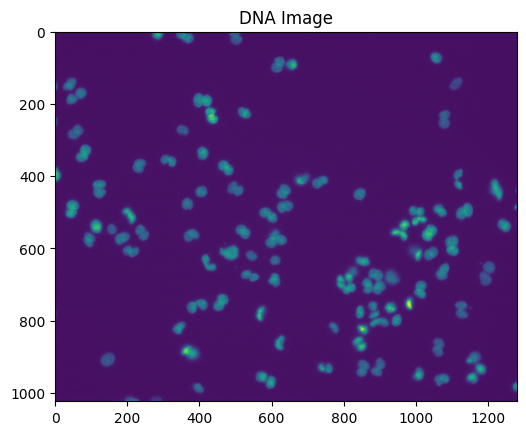

In [430]:
dna_path = str(Path(root_directory) / dna_images.iloc[0])
img = cv2.imread(dna_path, cv2.IMREAD_UNCHANGED)

print(img.shape, img.dtype, img.min(), img.max())

plt.title("DNA Image")
plt.imshow(img)

(1024, 1280) uint16 704 55600


[ WARN:0@47118.909] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 317 (0x13d) encountered
[ WARN:0@47118.909] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33628 (0x835c) encountered
[ WARN:0@47118.909] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "DateTime" contains null byte in value; value incorrectly truncated during reading due to implementation limitations


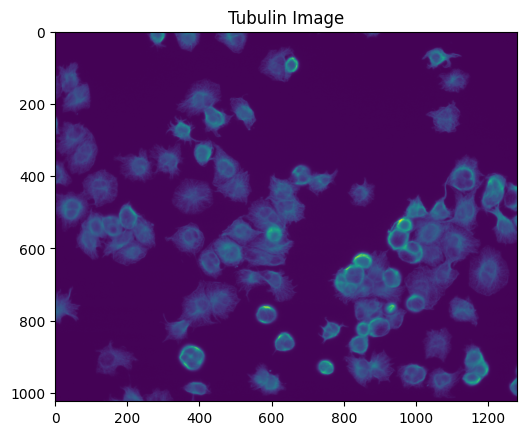

In [431]:
tubulin_path = str(Path(root_directory) / tubulin_images.iloc[0])
img = cv2.imread(tubulin_path, cv2.IMREAD_UNCHANGED)

print(img.shape, img.dtype, img.min(), img.max())

plt.title("Tubulin Image")
plt.imshow(img)

(1024, 1280) uint16 272 38432


[ WARN:0@47119.043] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 317 (0x13d) encountered
[ WARN:0@47119.043] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33628 (0x835c) encountered
[ WARN:0@47119.043] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "DateTime" contains null byte in value; value incorrectly truncated during reading due to implementation limitations


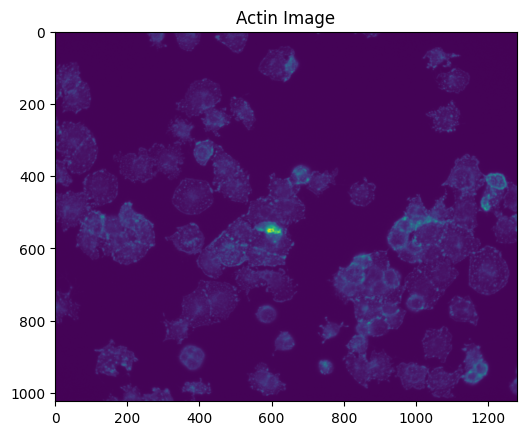

In [432]:
actin_images_path = str(Path(root_directory) / actin_images.iloc[0])
img = cv2.imread(actin_images_path, cv2.IMREAD_UNCHANGED)

print(img.shape, img.dtype, img.min(), img.max())

plt.title("Actin Image")
plt.imshow(img)

In [433]:
#Let's check the drug effect of week 1 on all cells
week_one = final_data[final_data['week'] ==1]

Now that we can see the images of the DNA, Actin and Tubulin we also want to check which drug was being used for it and whether they look visually similar or not


In [444]:
def plate_layout(df, plate):
    d = df[df["Image_Metadata_Plate_DAPI"] == plate].drop_duplicates(
        subset=["Image_Metadata_Well_DAPI"]
    ).copy()

    d["row"] = d["Image_Metadata_Well_DAPI"].str[0]
    d["col"] = d["Image_Metadata_Well_DAPI"].str[1:].astype(int)
    d["label"] = d["compound"].str.slice(0, 8) + "\n" + d["concentration"].astype(str)

    labels = d.pivot(index="row", columns="col", values="label")
    codes = d.pivot(index="row", columns="col", values="compound").apply(
        lambda s: s.astype("category").cat.codes
    )

    plt.figure(figsize=(14, 6))
    sns.heatmap(codes, annot=labels, fmt="", cbar=False,
                cmap="tab20", linewidths=1, linecolor="white",
                annot_kws={"fontsize": 7})
    plt.title(plate)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.tight_layout()
    plt.show()

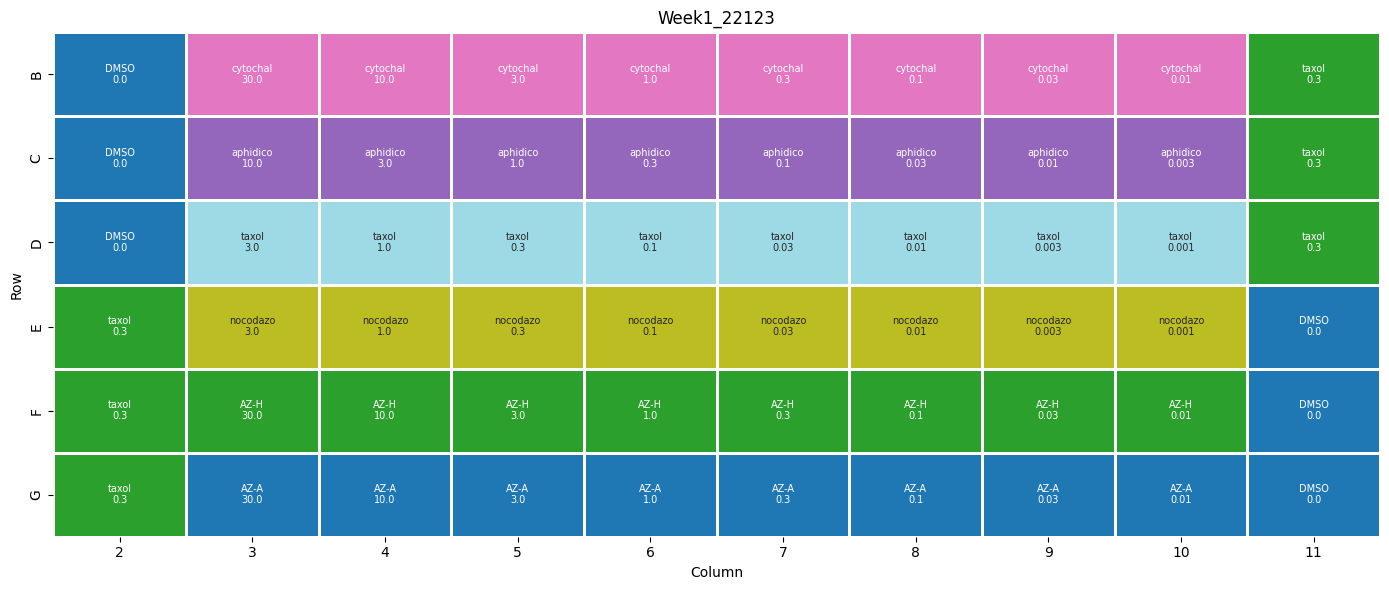

In [445]:
plate_layout(image_meta, "Week1_22123")

In [455]:
image_meta["week"] = image_meta["Image_Metadata_Plate_DAPI"].str.split("_").str[0]

In [ ]:
image_meta[image_meta["week"] == "Week1"].groupby()

In [496]:
image_meta.groupby("week")["Image_Metadata_Plate_DAPI"].nunique()

week
Week1     6
Week10    3
Week2     6
Week3     6
Week4     6
Week5     6
Week6     6
Week7     5
Week8     5
Week9     6
Name: Image_Metadata_Plate_DAPI, dtype: int64

In [493]:
#Let's check the number of drugs used in one week
image_meta[image_meta["week"]=="Week1"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week1_22123                      [aphidicolin, cytochalasin B, nocodazole, taxol, AZ-A, AZ-H, DMSO]
Week1_22141                      [aphidicolin, cytochalasin B, nocodazole, taxol, AZ-A, AZ-H, DMSO]
Week1_22161                      [aphidicolin, cytochalasin B, nocodazole, taxol, AZ-A, AZ-H, DMSO]
Week1_22361    [colchicine, doxorubicin, epothilone B, latrunculin B, monastrol, AZ-I, taxol, DMSO]
Week1_22381    [colchicine, doxorubicin, epothilone B, latrunculin B, monastrol, AZ-I, taxol, DMSO]
Week1_22401    [colchicine, doxorubicin, epothilone B, latrunculin B, monastrol, AZ-I, taxol, DMSO]
Name: compound, dtype: object

In [494]:
image_meta[image_meta["week"]=="Week2"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week2_24121    [ALLN, cytochalasin D, genistein, methotrexate, rapamycin, vinblastine, taxol, DMSO]
Week2_24141    [ALLN, cytochalasin D, genistein, methotrexate, rapamycin, vinblastine, taxol, DMSO]
Week2_24161    [ALLN, cytochalasin D, genistein, methotrexate, rapamycin, vinblastine, taxol, DMSO]
Week2_24361     [brefeldin A, herbimycin A, jasplakinolide, MG-132, roscovitine, AZ-B, taxol, DMSO]
Week2_24381     [brefeldin A, herbimycin A, jasplakinolide, MG-132, roscovitine, AZ-B, taxol, DMSO]
Week2_24401     [brefeldin A, herbimycin A, jasplakinolide, MG-132, roscovitine, AZ-B, taxol, DMSO]
Name: compound, dtype: object

In [497]:
image_meta[image_meta["week"]=="Week3"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week3_25421          [etoposide, staurosporine, UO-126, vincristine, AZ841, AZ-C, taxol, DMSO]
Week3_25441          [etoposide, staurosporine, UO-126, vincristine, AZ841, AZ-C, taxol, DMSO]
Week3_25461          [etoposide, staurosporine, UO-126, vincristine, AZ841, AZ-C, taxol, DMSO]
Week3_25681    [chlorambucil, cisplatin, demecolcine, emetine, PD-98059, Y-27632, taxol, DMSO]
Week3_25701    [chlorambucil, cisplatin, demecolcine, emetine, PD-98059, Y-27632, taxol, DMSO]
Week3_25721    [chlorambucil, cisplatin, demecolcine, emetine, PD-98059, Y-27632, taxol, DMSO]
Name: compound, dtype: object

In [498]:
image_meta[image_meta["week"]=="Week4"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week4_27481         [5-fluorouracil, AG-1478, anisomycin, indirubin monoxime, olomoucine, tunicamycin, taxol, DMSO]
Week4_27521         [5-fluorouracil, AG-1478, anisomycin, indirubin monoxime, olomoucine, tunicamycin, taxol, DMSO]
Week4_27542         [5-fluorouracil, AG-1478, anisomycin, indirubin monoxime, olomoucine, tunicamycin, taxol, DMSO]
Week4_27801    [caspase inhibitor 1 (ZVAD), cyclohexamide, mitomycin C, neomycin, okadaic acid, AZ258, taxol, DMSO]
Week4_27821    [caspase inhibitor 1 (ZVAD), cyclohexamide, mitomycin C, neomycin, okadaic acid, AZ258, taxol, DMSO]
Week4_27861    [caspase inhibitor 1 (ZVAD), cyclohexamide, mitomycin C, neomycin, okadaic acid, AZ258, taxol, DMSO]
Name: compound, dtype: object

In [499]:
image_meta[image_meta["week"]=="Week5"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week5_28901              [LY-294002, raloxifene, SB-202190, AZ701, AZ-J, AZ-K, taxol, DMSO]
Week5_28921              [LY-294002, raloxifene, SB-202190, AZ701, AZ-J, AZ-K, taxol, DMSO]
Week5_28961              [LY-294002, raloxifene, SB-202190, AZ701, AZ-J, AZ-K, taxol, DMSO]
Week5_29301    [aloisine A, ICI-182,780, methoxylamine, SB-203580, AZ-L, AZ-M, taxol, DMSO]
Week5_29321    [aloisine A, ICI-182,780, methoxylamine, SB-203580, AZ-L, AZ-M, taxol, DMSO]
Week5_29341    [aloisine A, ICI-182,780, methoxylamine, SB-203580, AZ-L, AZ-M, taxol, DMSO]
Name: compound, dtype: object

In [500]:
image_meta[image_meta["week"]=="Week6"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week6_31641                      [bleomycin, hydroxyurea, lactacystin, sodium fluoride, SP-600125, trichostatin, taxol, DMSO]
Week6_31661                      [bleomycin, hydroxyurea, lactacystin, sodium fluoride, SP-600125, trichostatin, taxol, DMSO]
Week6_31681                      [bleomycin, hydroxyurea, lactacystin, sodium fluoride, SP-600125, trichostatin, taxol, DMSO]
Week6_32061    [acyclovir, atropine, calpain inhibitor 2 (ALLM), podophyllotoxin, sodium butyrate, taurocholate, taxol, DMSO]
Week6_32121    [acyclovir, atropine, calpain inhibitor 2 (ALLM), podophyllotoxin, sodium butyrate, taurocholate, taxol, DMSO]
Week6_32161    [acyclovir, atropine, calpain inhibitor 2 (ALLM), podophyllotoxin, sodium butyrate, taurocholate, taxol, DMSO]
Name: compound, dtype: object

In [501]:
image_meta[image_meta["week"]=="Week7"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week7_34341       [arabinofuranosylcytosine, docetaxel, forskolin, proteasome inhibitor I, puromycin, AZ-N, taxol, DMSO]
Week7_34381       [arabinofuranosylcytosine, docetaxel, forskolin, proteasome inhibitor I, puromycin, AZ-N, taxol, DMSO]
Week7_34641       [arabinofuranosylcytosine, docetaxel, forskolin, proteasome inhibitor I, puromycin, AZ-N, taxol, DMSO]
Week7_34661    [alsterpaullone, bryostatin, chloramphenicol, deoxymannojirimycin, PD-169316, valproic acid, taxol, DMSO]
Week7_34681    [alsterpaullone, bryostatin, chloramphenicol, deoxymannojirimycin, PD-169316, valproic acid, taxol, DMSO]
Name: compound, dtype: object

In [502]:
image_meta[image_meta["week"]=="Week8"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week8_38203    [camptothecin, Cdk1 inhibitor III, 3,3'-diaminobenzidine, leupeptin, nystatin, quercetin, taxol, DMSO]
Week8_38221    [camptothecin, Cdk1 inhibitor III, 3,3'-diaminobenzidine, leupeptin, nystatin, quercetin, taxol, DMSO]
Week8_38241    [camptothecin, Cdk1 inhibitor III, 3,3'-diaminobenzidine, leupeptin, nystatin, quercetin, taxol, DMSO]
Week8_38341                              [bohemine, calpeptin, cyclophosphamide, filipin, PP-2, UNKNOWN, taxol, DMSO]
Week8_38342                              [bohemine, calpeptin, cyclophosphamide, filipin, PP-2, UNKNOWN, taxol, DMSO]
Name: compound, dtype: object

There is a drug called UNKNOWN in Week 8

In [503]:
image_meta[image_meta["week"]=="Week9"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week9_39206              [AG-1478, cathepsin inhibitor I, H-7, mevinolin/lovastatin, AZ235, AZ-O, taxol, DMSO]
Week9_39221              [AG-1478, cathepsin inhibitor I, H-7, mevinolin/lovastatin, AZ235, AZ-O, taxol, DMSO]
Week9_39222              [AG-1478, cathepsin inhibitor I, H-7, mevinolin/lovastatin, AZ235, AZ-O, taxol, DMSO]
Week9_39282    [carboplatin, deoxynojirimycin, floxuridine, mitoxantrone, PD-150606, simvastatin, taxol, DMSO]
Week9_39283    [carboplatin, deoxynojirimycin, floxuridine, mitoxantrone, PD-150606, simvastatin, taxol, DMSO]
Week9_39301    [carboplatin, deoxynojirimycin, floxuridine, mitoxantrone, PD-150606, simvastatin, taxol, DMSO]
Name: compound, dtype: object

In [495]:
image_meta[image_meta["week"]=="Week10"].groupby("Image_Metadata_Plate_DAPI")["compound"].unique()

Image_Metadata_Plate_DAPI
Week10_40111    [Cdk1/2 inhibitor (NU6102), monastrol, temozolomide, AZ138, AZ-U, TKK, taxol, DMSO]
Week10_40115    [Cdk1/2 inhibitor (NU6102), monastrol, temozolomide, AZ138, AZ-U, TKK, taxol, DMSO]
Week10_40119    [Cdk1/2 inhibitor (NU6102), monastrol, temozolomide, AZ138, AZ-U, TKK, taxol, DMSO]
Name: compound, dtype: object

- Aphodocolin
- cytochalasin B
- nocodazole
- taxol
- AZ-A
- AZ-H
- DMSO
- colchicine
- doxorubicin
- epothilone B
- latrunculin B
- monastrol
- AZ-I


Looking at the experiment, it was repeated atleast 2 times or more for each drug to get the data

In [ ]:
image_meta['Image_Metadata_Plate_DAPI'].unique()


<ArrowStringArray>
[ 'Week4_27481',  'Week4_27521',  'Week4_27542',  'Week6_32061',
  'Week6_32121',  'Week6_32161',  'Week9_39206',  'Week9_39221',
  'Week9_39222',  'Week2_24121',  'Week2_24141',  'Week2_24161',
  'Week5_29301',  'Week5_29321',  'Week5_29341',  'Week7_34661',
  'Week7_34681',  'Week1_22123',  'Week1_22141',  'Week1_22161',
  'Week7_34341',  'Week7_34381',  'Week7_34641',  'Week6_31641',
  'Week6_31661',  'Week6_31681',  'Week8_38341',  'Week8_38342',
  'Week2_24361',  'Week2_24381',  'Week2_24401',  'Week8_38203',
  'Week8_38221',  'Week8_38241',  'Week9_39282',  'Week9_39283',
  'Week9_39301',  'Week4_27801',  'Week4_27821',  'Week4_27861',
 'Week10_40111', 'Week10_40115', 'Week10_40119',  'Week3_25681',
  'Week3_25701',  'Week3_25721',  'Week1_22361',  'Week1_22381',
  'Week1_22401',  'Week3_25421',  'Week3_25441',  'Week3_25461',
  'Week5_28901',  'Week5_28921',  'Week5_28961']
Length: 55, dtype: str

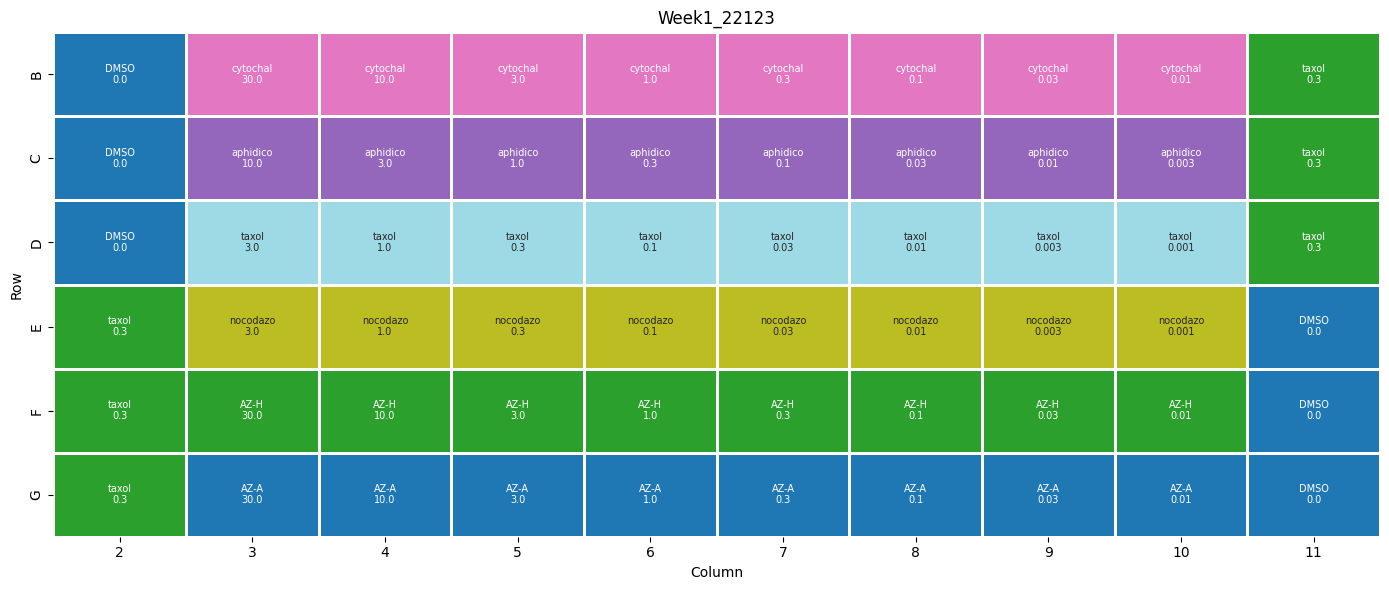

In [467]:
plate_layout(image_meta, "Week1_22123")

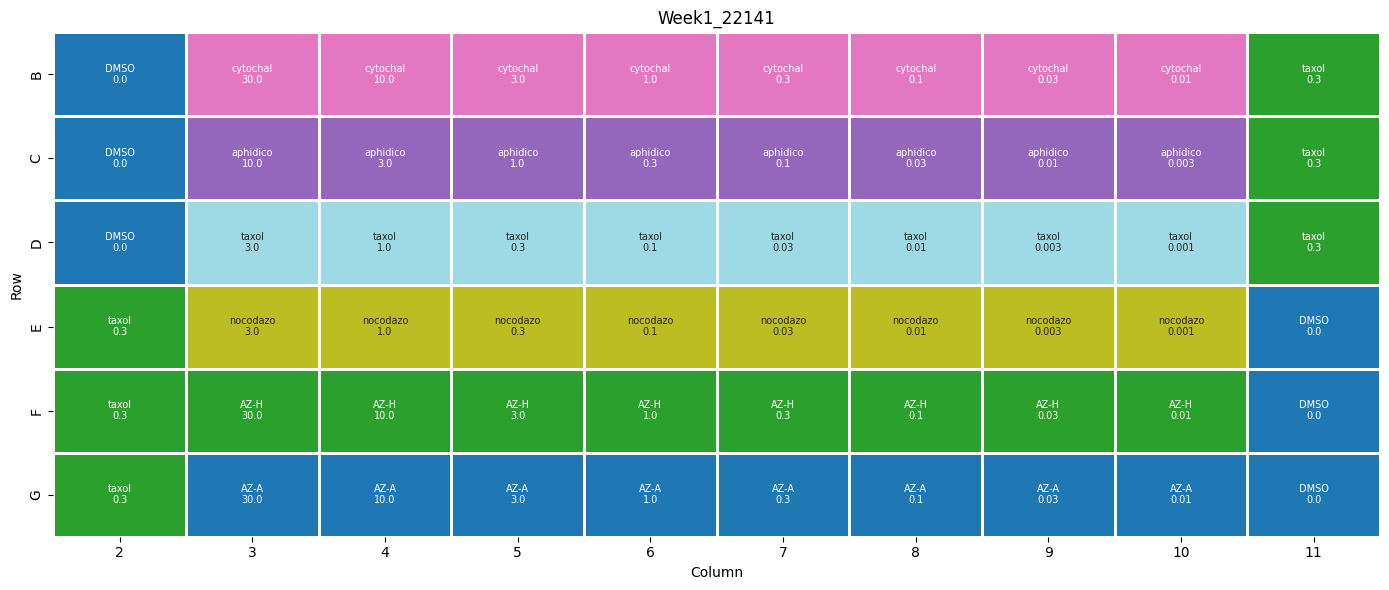

In [468]:
plate_layout(image_meta, "Week1_22141")

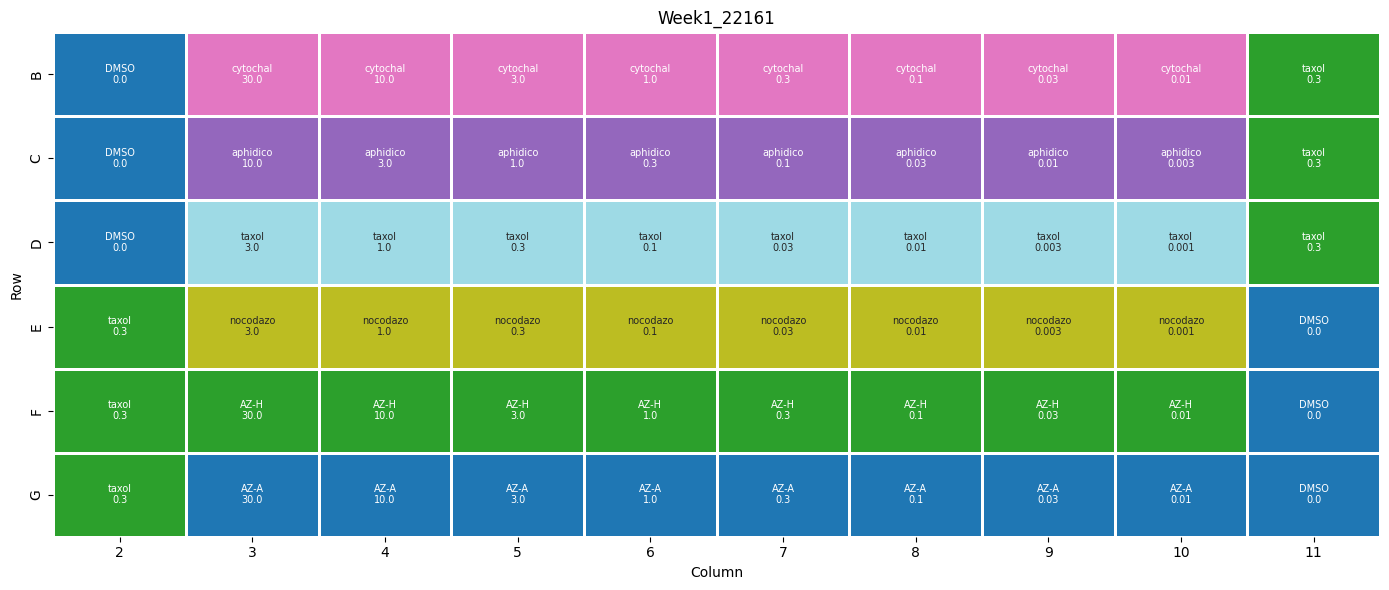

In [469]:
plate_layout(image_meta, "Week1_22161")

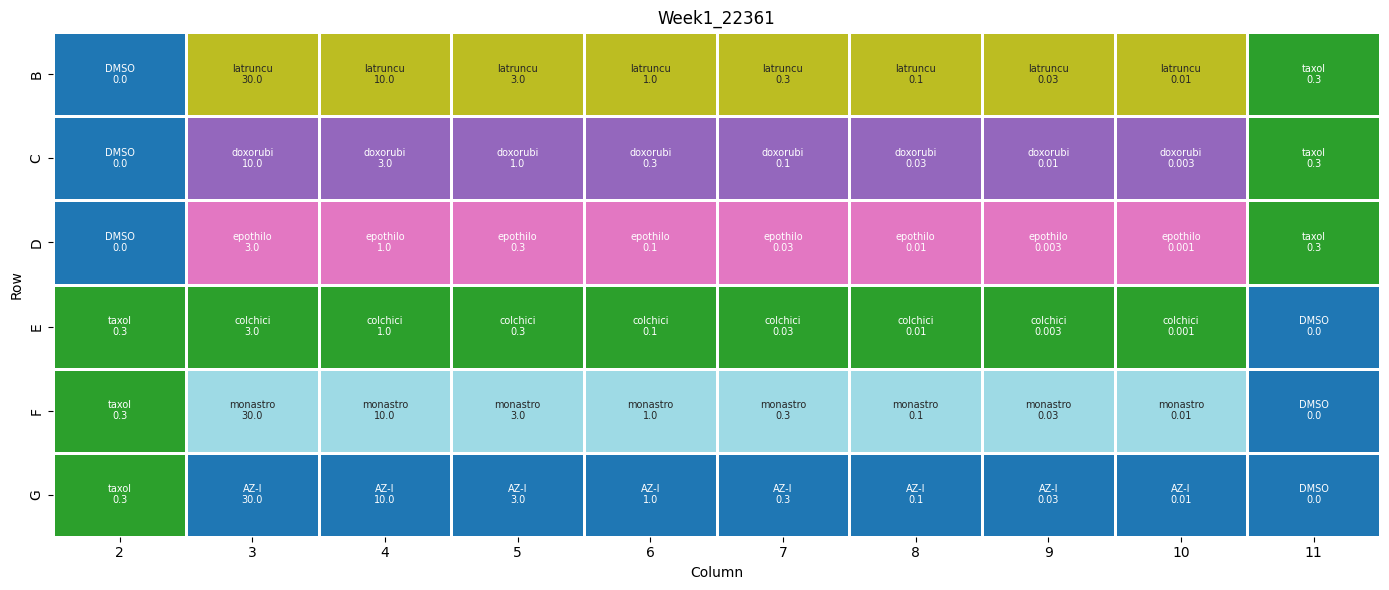

In [ ]:
plate_layout(image_meta, "Week1_22361")

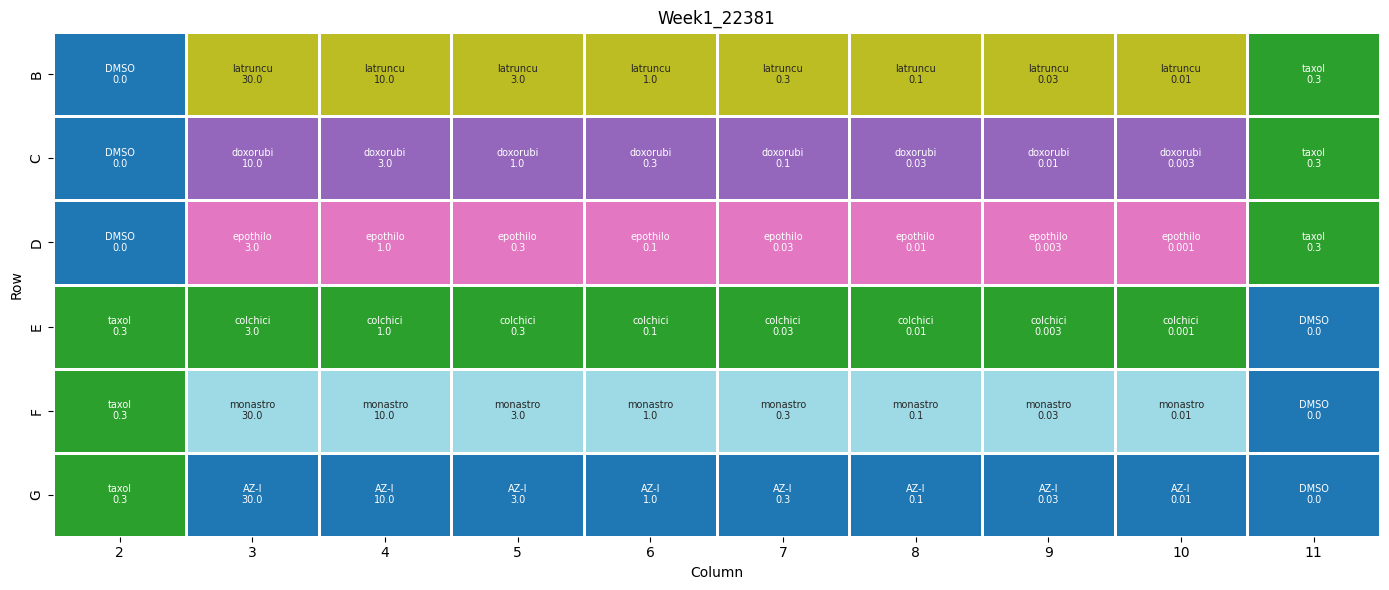

In [471]:
plate_layout(image_meta, "Week1_22381")

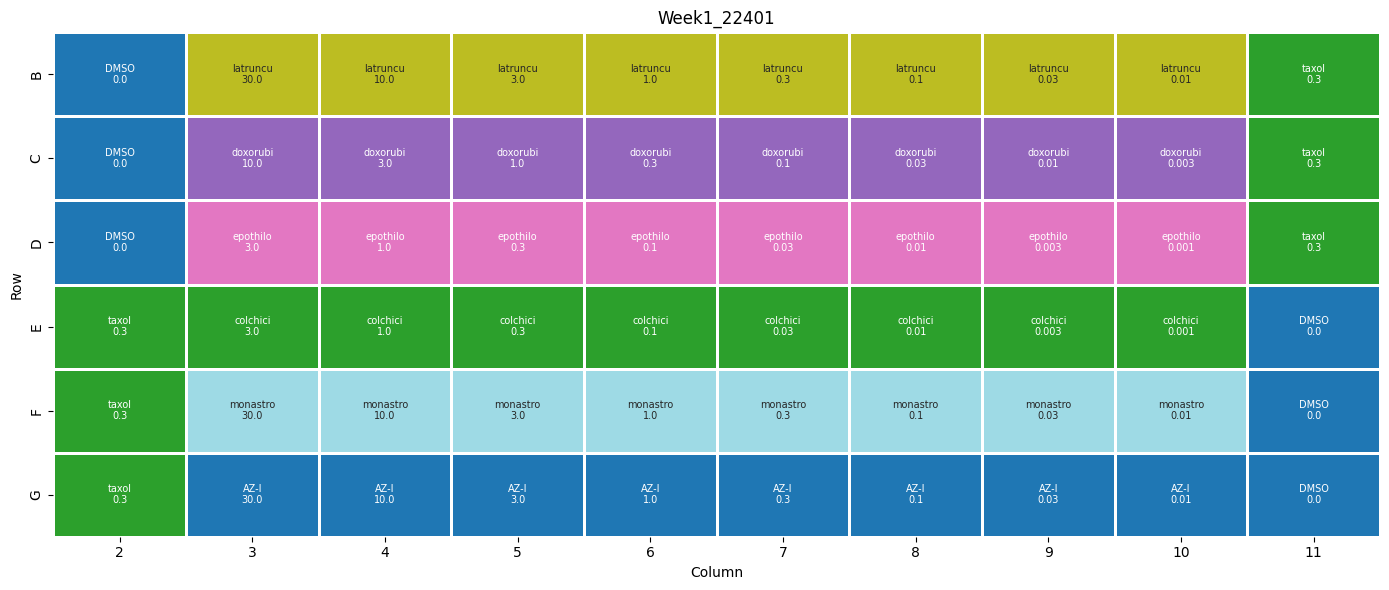

In [472]:
plate_layout(image_meta, "Week1_22401")

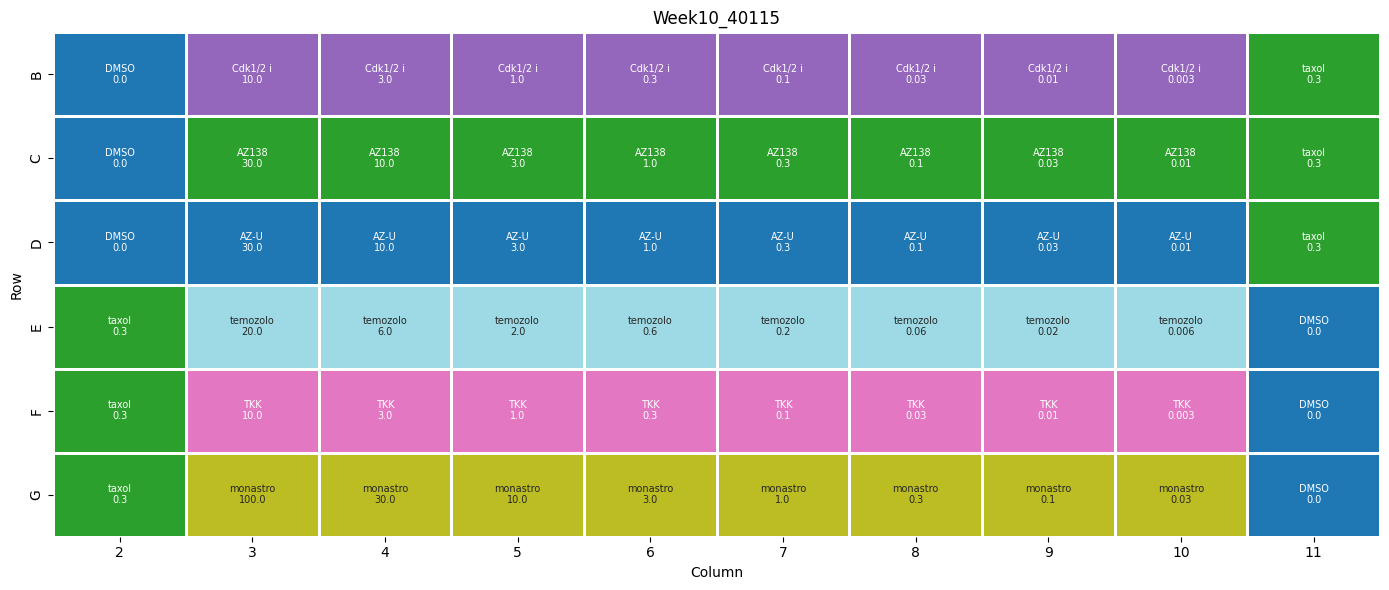

In [491]:
plate_layout(image_meta, "Week10_40115")